In [112]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [113]:
flower_data = load_iris()
features = flower_data.data
both = flower_data.target
input_columns = flower_data.feature_names
output_both = flower_data.target_names

In [114]:
train_features, test_features, train_both, test_both = train_test_split(features, both, test_size=0.3, random_state=42)

In [115]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_features)
X_test_scaled = scaler.transform(test_features)

In [116]:
def train_evaluate_models(train_features, test_features, train_both, test_both):
    models = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(random_state=42),
        'SVM': SVC(random_state=42)
    }

    results = {}

    for name, model in models.items():
        model.fit(train_features, train_both)
        y_pred = model.predict(test_features)

        results[name] = {
            'Accuracy': accuracy_score(test_both, y_pred),
            'Precision': precision_score(test_both, y_pred, average='weighted'),
            'Recall': recall_score(test_both, y_pred, average='weighted'),
            'F1-Score': f1_score(test_both, y_pred, average='weighted'),
            'Confusion Matrix': confusion_matrix(test_both, y_pred),
            'Classification Report': classification_report(test_both, y_pred, target_names=output_both)
        }

    return results

In [117]:
results_original = train_evaluate_models(X_train_scaled, X_test_scaled, train_both, test_both)

In [118]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)
results_pca = train_evaluate_models(X_train_pca, X_test_pca, train_both, test_both)

In [119]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train_scaled, train_both)
X_test_lda = lda.transform(X_test_scaled)
results_lda = train_evaluate_models(X_train_lda, X_test_lda, train_both, test_both)

In [120]:
def create_comparison_dataframe(metric_name):
    data = {
        'Original': [results_original[model][metric_name] for model in results_original],
        'PCA': [results_pca[model][metric_name] for model in results_pca],
        'LDA': [results_lda[model][metric_name] for model in results_lda]
    }
    return pd.DataFrame(data, index=list(results_original.keys()))

In [121]:
accuracy_df = create_comparison_dataframe('Accuracy')
precision_df = create_comparison_dataframe('Precision')
recall_df = create_comparison_dataframe('Recall')
f1_df = create_comparison_dataframe('F1-Score')

In [122]:
print("ACCURACY COMPARISON")
print("==================")
print(accuracy_df.round(4))

print("\nPRECISION COMPARISON")
print("===================")
print(precision_df.round(4))

print("\nRECALL COMPARISON")
print("===============")
print(recall_df.round(4))

print("\nF1-SCORE COMPARISON")
print("=================")
print(f1_df.round(4))

ACCURACY COMPARISON
                     Original     PCA     LDA
Logistic Regression       1.0  0.9111  1.0000
Decision Tree             1.0  0.9333  0.9556
Random Forest             1.0  0.9556  1.0000
SVM                       1.0  0.9333  1.0000

PRECISION COMPARISON
                     Original     PCA     LDA
Logistic Regression       1.0  0.9160  1.0000
Decision Tree             1.0  0.9347  0.9556
Random Forest             1.0  0.9615  1.0000
SVM                       1.0  0.9347  1.0000

RECALL COMPARISON
                     Original     PCA     LDA
Logistic Regression       1.0  0.9111  1.0000
Decision Tree             1.0  0.9333  0.9556
Random Forest             1.0  0.9556  1.0000
SVM                       1.0  0.9333  1.0000

F1-SCORE COMPARISON
                     Original     PCA     LDA
Logistic Regression       1.0  0.9106  1.0000
Decision Tree             1.0  0.9332  0.9556
Random Forest             1.0  0.9553  1.0000
SVM                       1.0  0.9332  1.000

In [123]:
print("\nCONFUSION MATRICES")
print("=================")
for method_name, results in [("Original", results_original),
                             ("PCA", results_pca),
                             ("LDA", results_lda)]:
    print(f"\n{method_name} Method:")
    for model_name, metrics in results.items():
        print(f"\n{model_name}:")
        cm = metrics['Confusion Matrix']
        print(cm)


CONFUSION MATRICES

Original Method:

Logistic Regression:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Decision Tree:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Random Forest:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

SVM:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

PCA Method:

Logistic Regression:
[[19  0  0]
 [ 0 10  3]
 [ 0  1 12]]

Decision Tree:
[[19  0  0]
 [ 0 11  2]
 [ 0  1 12]]

Random Forest:
[[19  0  0]
 [ 0 11  2]
 [ 0  0 13]]

SVM:
[[19  0  0]
 [ 0 11  2]
 [ 0  1 12]]

LDA Method:

Logistic Regression:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Decision Tree:
[[19  0  0]
 [ 0 12  1]
 [ 0  1 12]]

Random Forest:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

SVM:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [124]:
def plot_confusion_matrices(results, method_name, output_both):
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    axes = axes.flatten()

    for i, (model_name, metrics) in enumerate(results.items()):
        cm = metrics['Confusion Matrix']
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i])
        axes[i].set_title(f'{method_name} - {model_name}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('True')
        axes[i].set_xticks(range(len(output_both)))
        axes[i].set_yticks(range(len(output_both)))
        axes[i].set_xticklabels(output_both)
        axes[i].set_yticklabels(output_both)

    plt.tight_layout()
    return fig


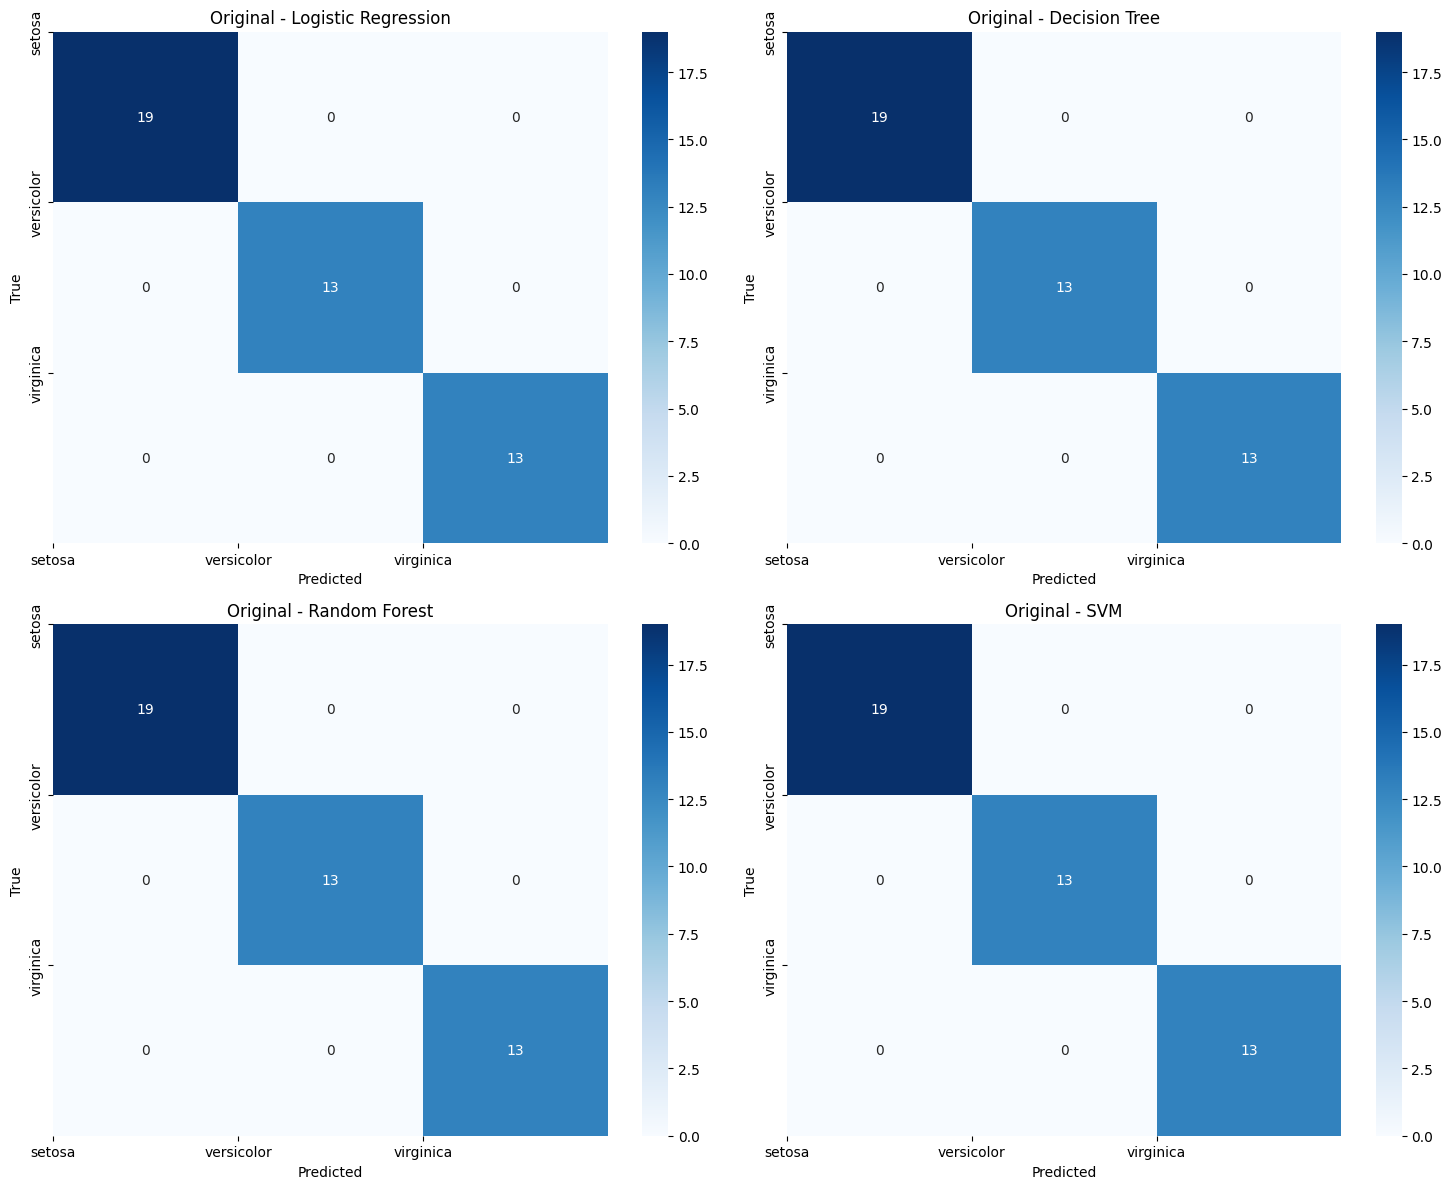

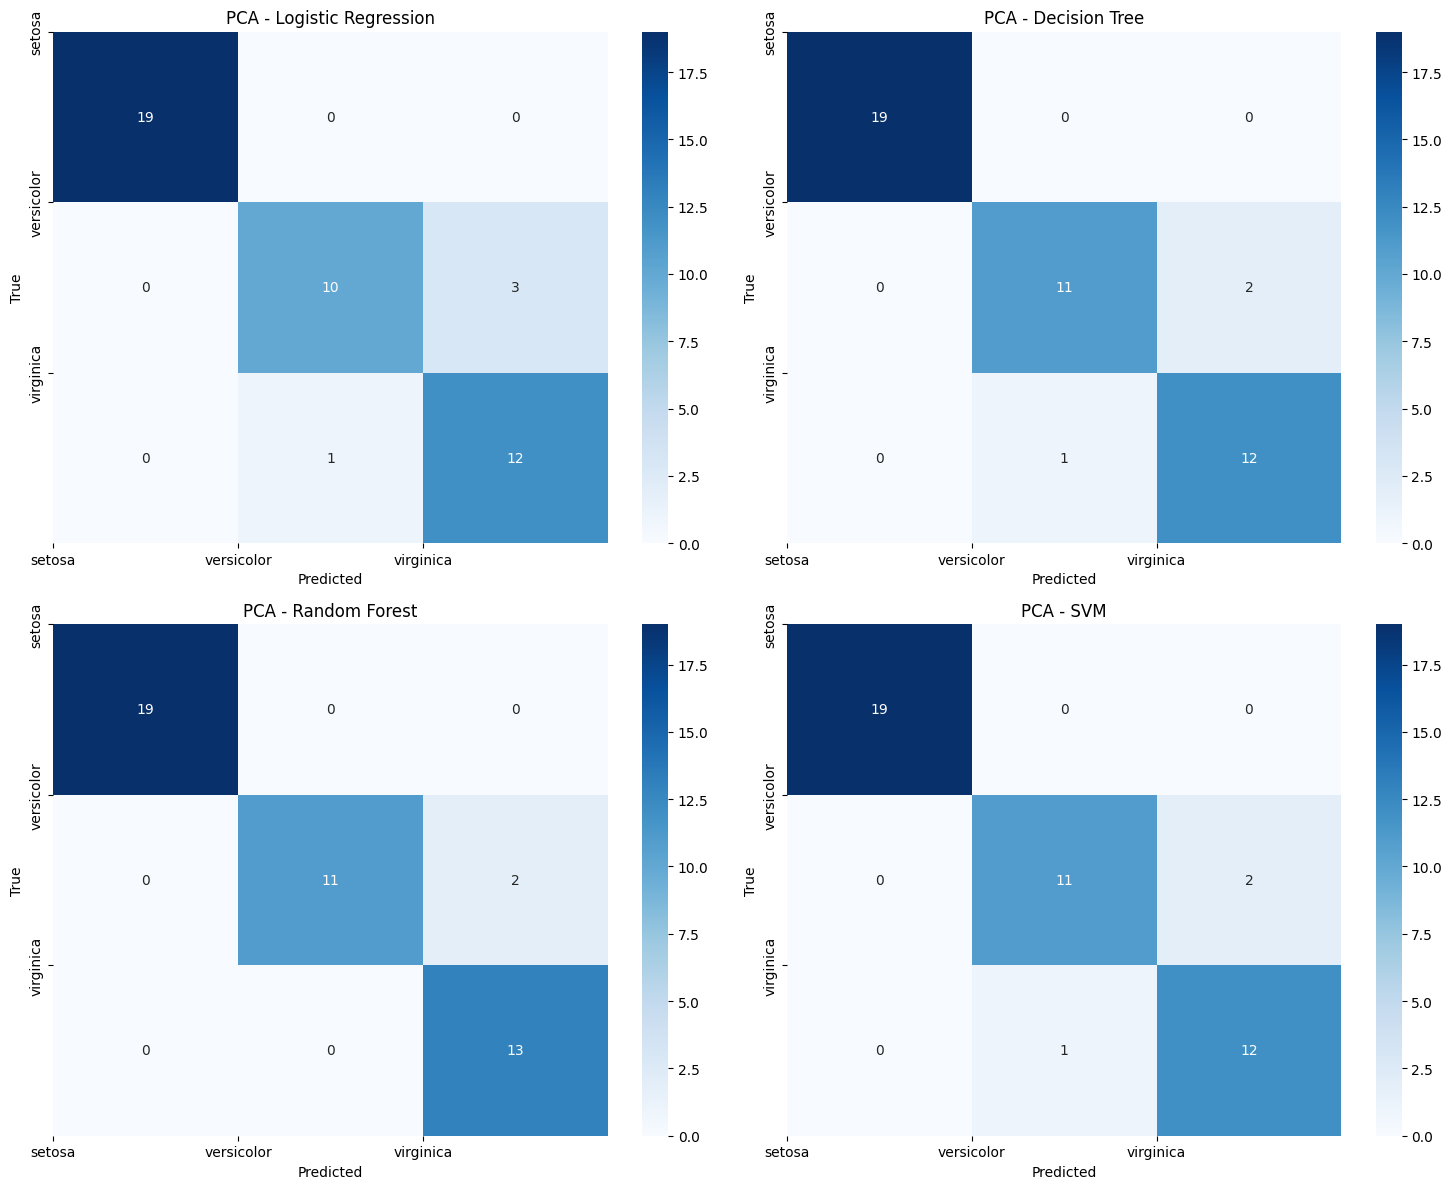

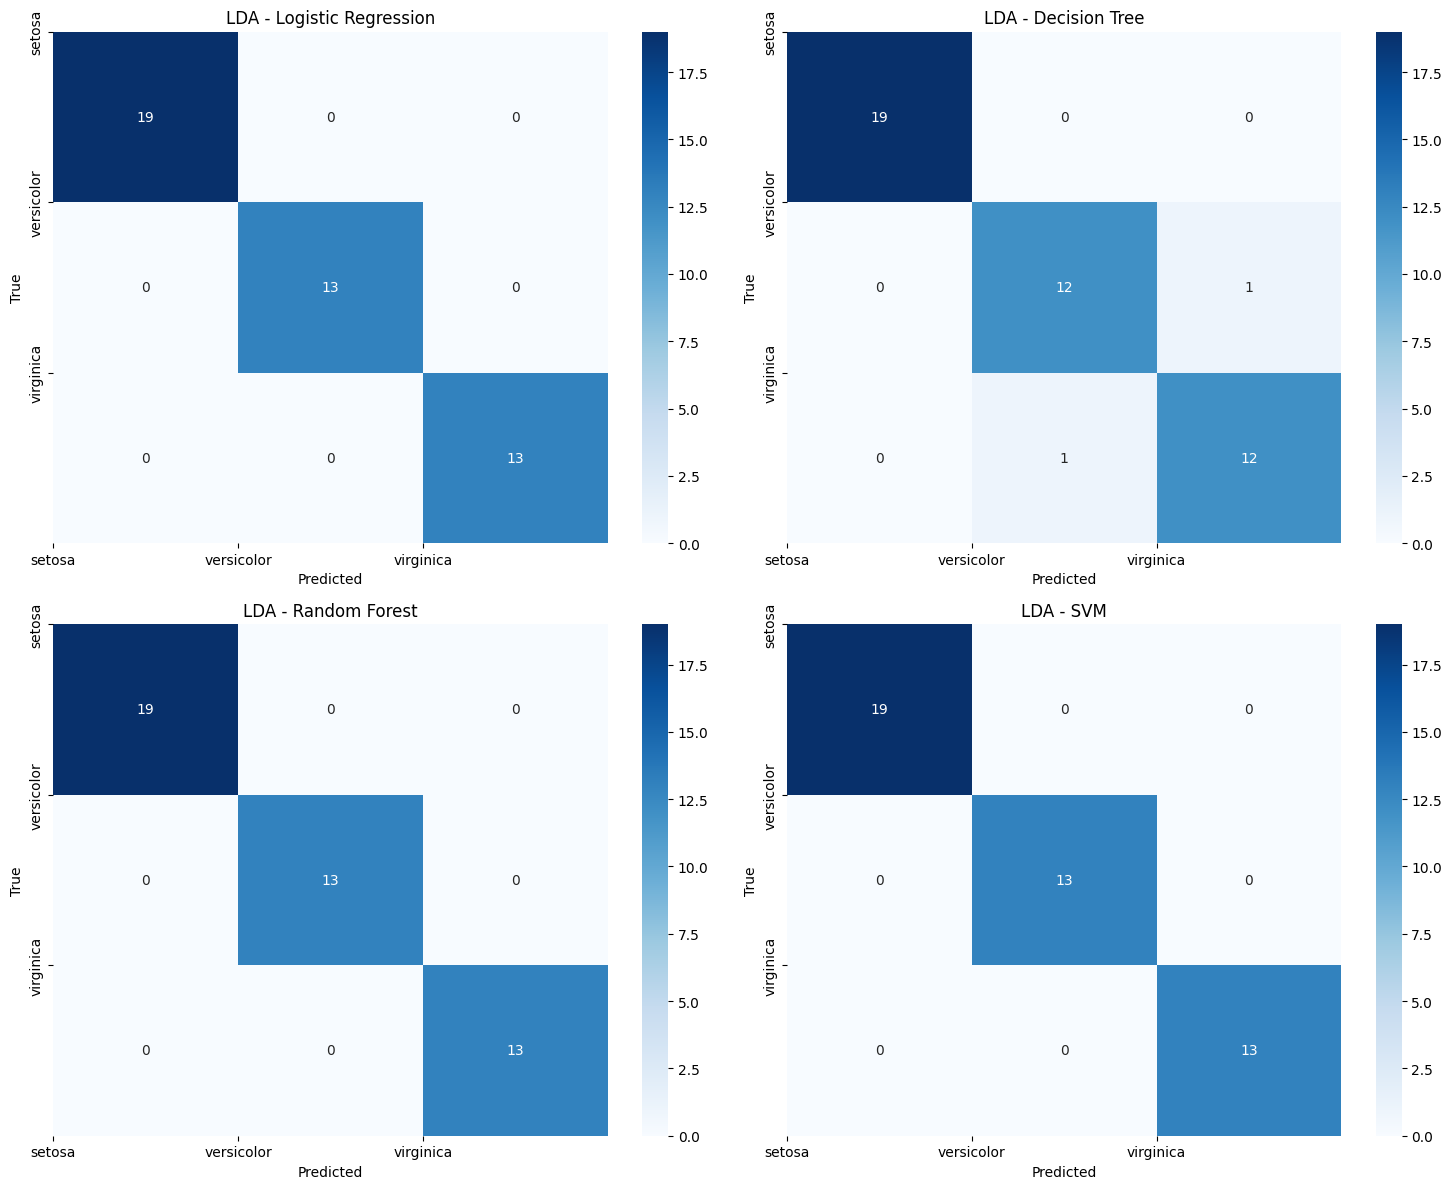

In [125]:
plot_confusion_matrices(results_original, 'Original',output_both)
plt.show()

plot_confusion_matrices(results_pca, 'PCA',output_both)
plt.show()

plot_confusion_matrices(results_lda, 'LDA',output_both)
plt.show()

In [126]:
def plot_dimensionality_reduction():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

    colors = ['navy', 'turquoise', 'darkorange']

    for i, color in enumerate(colors):
        ax1.scatter(X_train_pca[train_both == i, 0], X_train_pca[train_both == i, 1],
                   color=color, alpha=0.8, lw=2, label=output_both[i])
    ax1.set_title('PCA Projection of Training Data')
    ax1.set_xlabel(f'PC1 (Explained Variance: {pca.explained_variance_ratio_[0]:.2f})')
    ax1.set_ylabel(f'PC2 (Explained Variance: {pca.explained_variance_ratio_[1]:.2f})')
    ax1.legend()
    ax1.grid(True)

    for i, color in enumerate(colors):
        ax2.scatter(X_train_lda[train_both == i, 0], X_train_lda[train_both == i, 1],
                   color=color, alpha=0.8, lw=2, label=output_both[i])
    ax2.set_title('LDA Projection of Training Data')
    ax2.set_xlabel('LD1')
    ax2.set_ylabel('LD2')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    return fig

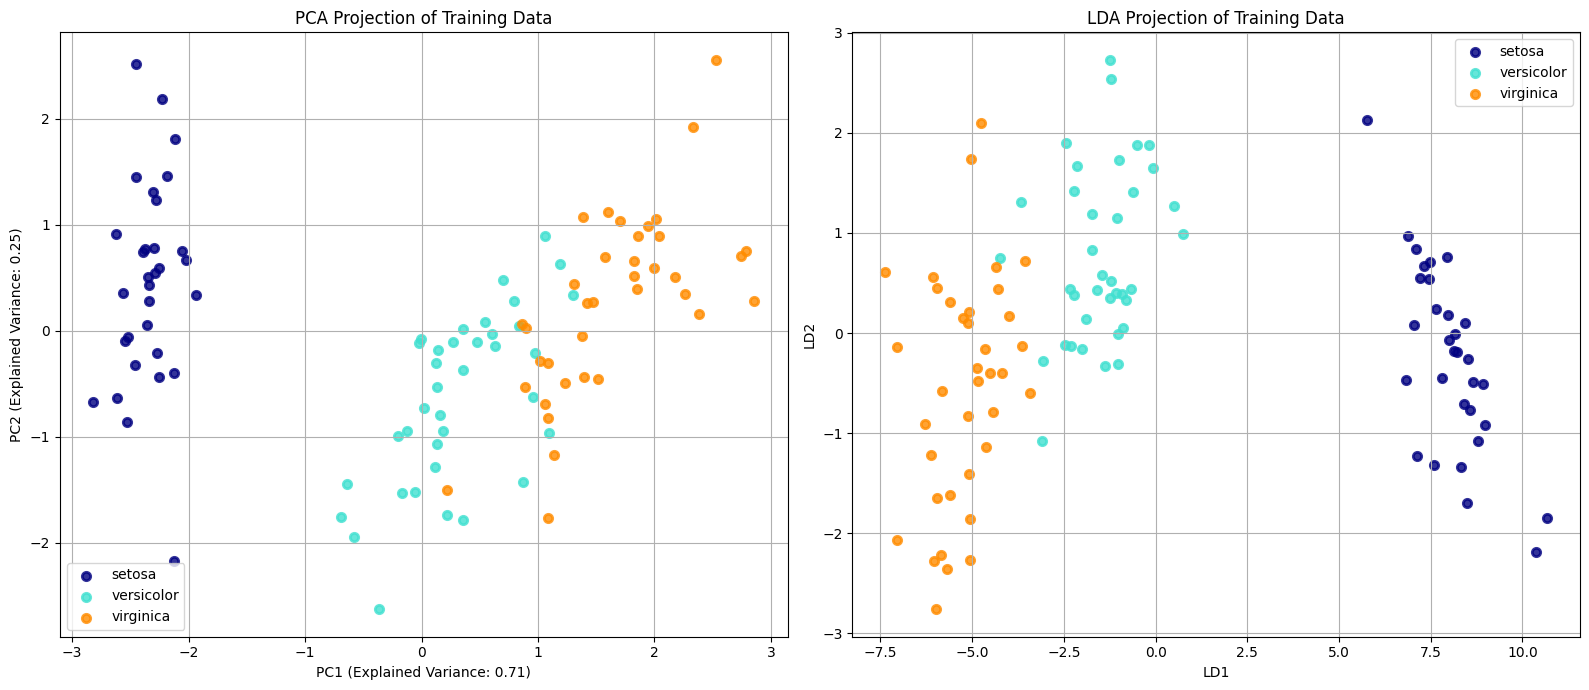

In [127]:
plot_dimensionality_reduction()
plt.show()

In [128]:
def plot_metrics_comparison():
    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    axes = axes.flatten()

    metrics = {
        'Accuracy': accuracy_df,
        'Precision': precision_df,
        'Recall': recall_df,
        'F1-Score': f1_df
    }

    for i, (metric_name, df) in enumerate(metrics.items()):
        df.plot(kind='bar', ax=axes[i], rot=0, colormap='viridis')
        axes[i].set_title(f'{metric_name} Comparison', fontsize=14)
        axes[i].set_ylabel(metric_name, fontsize=12)
        axes[i].set_ylim([0.7, 1.0])
        axes[i].grid(axis='both', linestyle='--', alpha=0.7)
        axes[i].legend(title='Method')

    plt.tight_layout()
    return fig

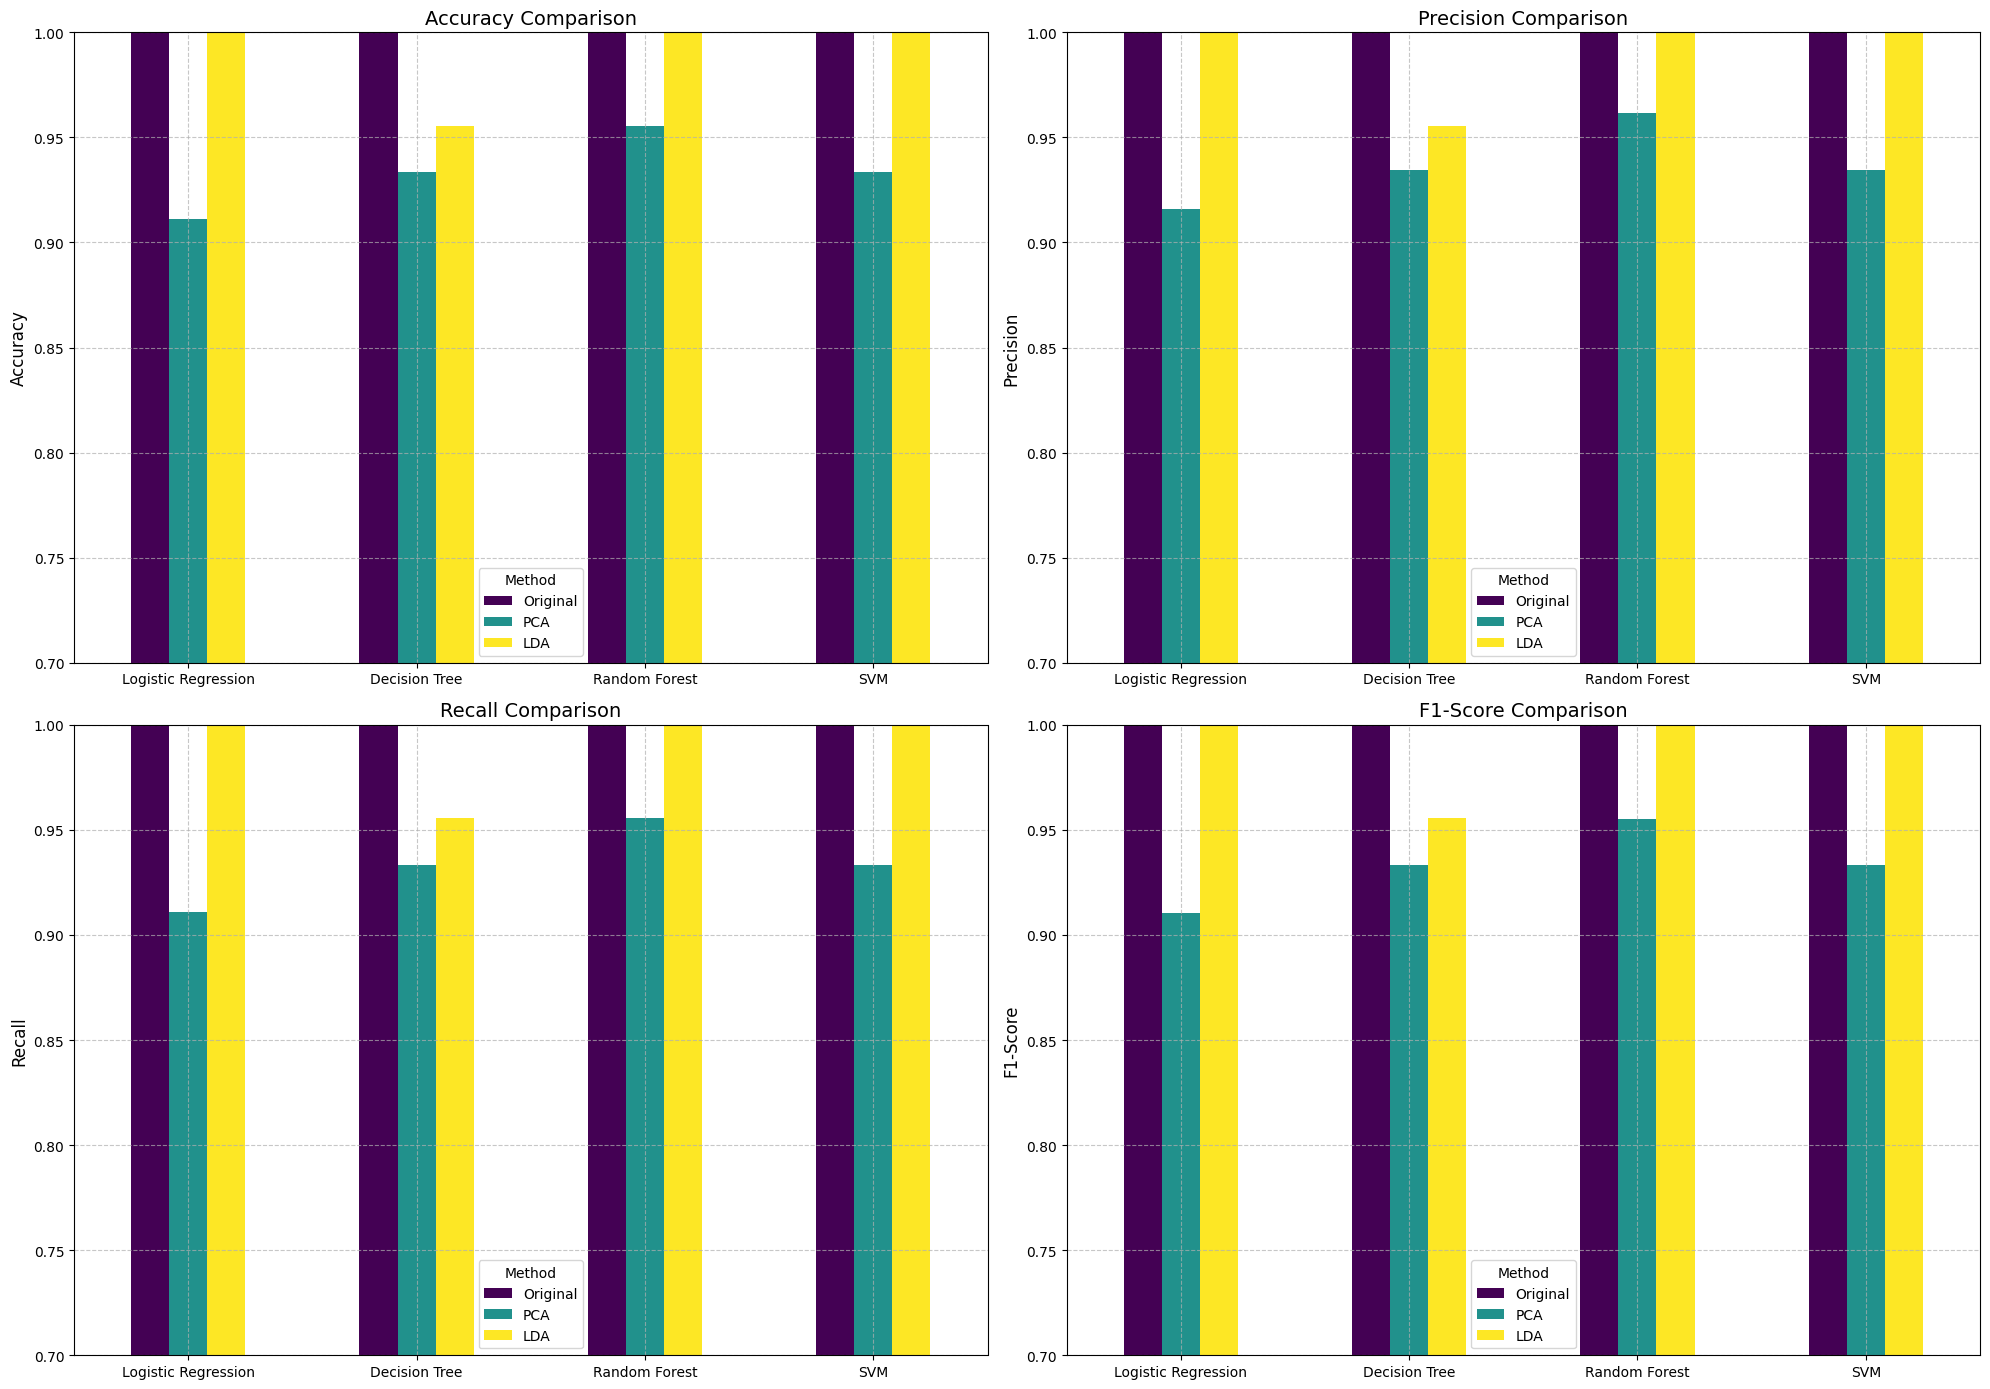

In [129]:
plot_metrics_comparison()
plt.show()

In [130]:
all_results = []
for model_name in results_original.keys():
    for method, results in [('Original', results_original), ('PCA', results_pca), ('LDA', results_lda)]:
        all_results.append({
            'Model': model_name,
            'Method': method,
            'Accuracy': results[model_name]['Accuracy'],
            'Precision': results[model_name]['Precision'],
            'Recall': results[model_name]['Recall'],
            'F1-Score': results[model_name]['F1-Score']
        })

summary_df = pd.DataFrame(all_results)

In [131]:
print("\nCOMPLETE SUMMARY OF RESULTS")
print("==========================")
print(summary_df.round(4))


COMPLETE SUMMARY OF RESULTS
                  Model    Method  Accuracy  Precision  Recall  F1-Score
0   Logistic Regression  Original    1.0000     1.0000  1.0000    1.0000
1   Logistic Regression       PCA    0.9111     0.9160  0.9111    0.9106
2   Logistic Regression       LDA    1.0000     1.0000  1.0000    1.0000
3         Decision Tree  Original    1.0000     1.0000  1.0000    1.0000
4         Decision Tree       PCA    0.9333     0.9347  0.9333    0.9332
5         Decision Tree       LDA    0.9556     0.9556  0.9556    0.9556
6         Random Forest  Original    1.0000     1.0000  1.0000    1.0000
7         Random Forest       PCA    0.9556     0.9615  0.9556    0.9553
8         Random Forest       LDA    1.0000     1.0000  1.0000    1.0000
9                   SVM  Original    1.0000     1.0000  1.0000    1.0000
10                  SVM       PCA    0.9333     0.9347  0.9333    0.9332
11                  SVM       LDA    1.0000     1.0000  1.0000    1.0000


In [132]:
avg_by_method = summary_df.groupby('Method')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].mean()
print("\nAVERAGE PERFORMANCE BY METHOD")
print("===========================")
print(avg_by_method.round(4))

avg_by_model = summary_df.groupby('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']].mean()
print("\nAVERAGE PERFORMANCE BY MODEL")
print("=========================")
print(avg_by_model.round(4))


AVERAGE PERFORMANCE BY METHOD
          Accuracy  Precision  Recall  F1-Score
Method                                         
LDA         0.9889     0.9889  0.9889    0.9889
Original    1.0000     1.0000  1.0000    1.0000
PCA         0.9333     0.9367  0.9333    0.9331

AVERAGE PERFORMANCE BY MODEL
                     Accuracy  Precision  Recall  F1-Score
Model                                                     
Decision Tree          0.9630     0.9634  0.9630    0.9629
Logistic Regression    0.9704     0.9720  0.9704    0.9702
Random Forest          0.9852     0.9872  0.9852    0.9851
SVM                    0.9778     0.9782  0.9778    0.9777


In [133]:
def plot_avg_performance():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

    avg_by_method.plot(kind='bar', ax=ax1, rot=0, colormap='viridis')
    ax1.set_title('Average Performance by Method', fontsize=14)
    ax1.set_ylabel('Score', fontsize=12)
    ax1.set_ylim([0.7, 1.0])
    ax1.grid(axis='both', linestyle='--', alpha=0.7)
    ax1.legend(title='Metric')

    avg_by_model.plot(kind='bar', ax=ax2, rot=0, colormap='viridis')
    ax2.set_title('Average Performance by Model', fontsize=14)
    ax2.set_ylabel('Score', fontsize=12)
    ax2.set_ylim([0.7, 1.0])
    ax2.grid(axis='both', linestyle='--', alpha=0.7)
    ax2.legend(title='Metric')

    plt.tight_layout()
    return fig

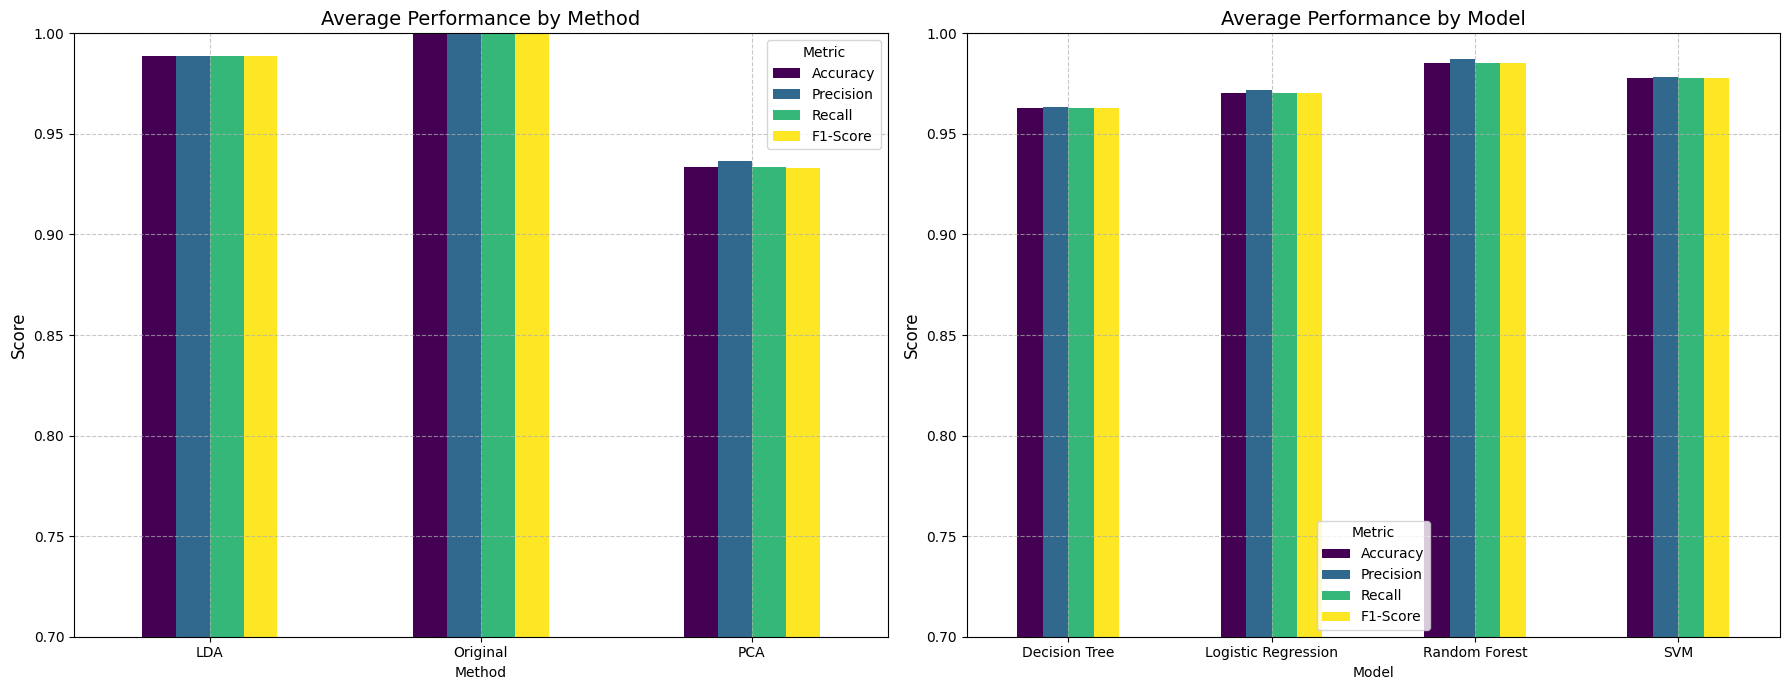

In [134]:
plot_avg_performance()
plt.show()

In [145]:
def plot_pca_variance():
    plt.figure(figsize=(8, 5))

    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)

    bars = plt.bar(range(1, len(explained_variance) + 1), explained_variance, alpha=0.7,
            label='Individual explained variance')
    plt.step(range(1, len(cumulative_variance) + 1), cumulative_variance, where='mid',
            label='Cumulative explained variance', color='red')

    plt.axhline(y=0.95, color='k', linestyle='--', alpha=0.7, label='95% Explained Variance')

    plt.ylabel('Explained variance ratio')
    plt.xlabel('Principal component')
    plt.title('PCA Explained Variance')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    return plt.gcf()

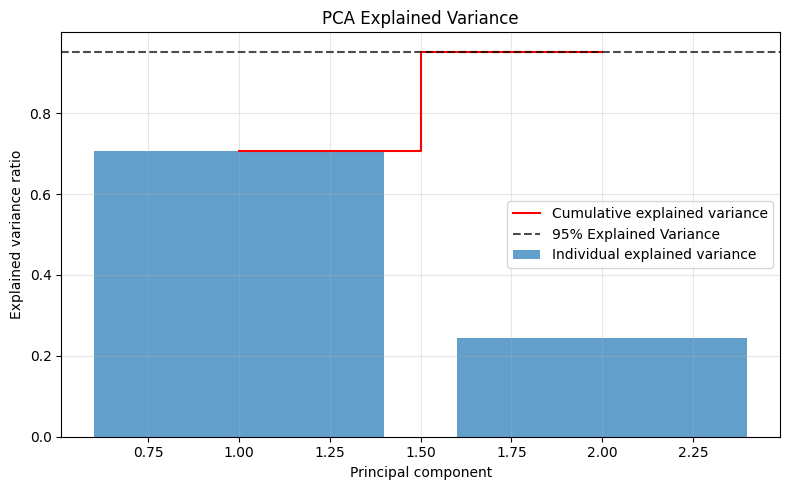

In [146]:
plot_pca_variance()
plt.show()

In [137]:
print("\nPCA EXPLAINED VARIANCE")
print("=====================")
print(f"Component 1: {pca.explained_variance_ratio_[0]:.4f}")
print(f"Component 2: {pca.explained_variance_ratio_[1]:.4f}")
print(f"Sum: {sum(pca.explained_variance_ratio_[:2]):.4f}")


PCA EXPLAINED VARIANCE
Component 1: 0.7070
Component 2: 0.2451
Sum: 0.9521


In [138]:
def plot_model_comparison_by_method():
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    methods = ['Original', 'PCA', 'LDA']
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

    for i, method in enumerate(methods):
        method_data = summary_df[summary_df['Method'] == method]

        # Create a dataframe suitable for plotting without pivot
        plot_data = method_data.set_index('Model')[metrics]

        plot_data.plot(kind='bar', ax=axes[i], rot=0, colormap='viridis')
        axes[i].set_title(f'{method} Method Performance', fontsize=14)
        axes[i].set_ylabel('Score', fontsize=12)
        axes[i].set_ylim([0.7, 1.0])
        axes[i].grid(axis='both', linestyle='--', alpha=0.7)
        axes[i].legend(title='Metric')

    plt.tight_layout()
    return fig

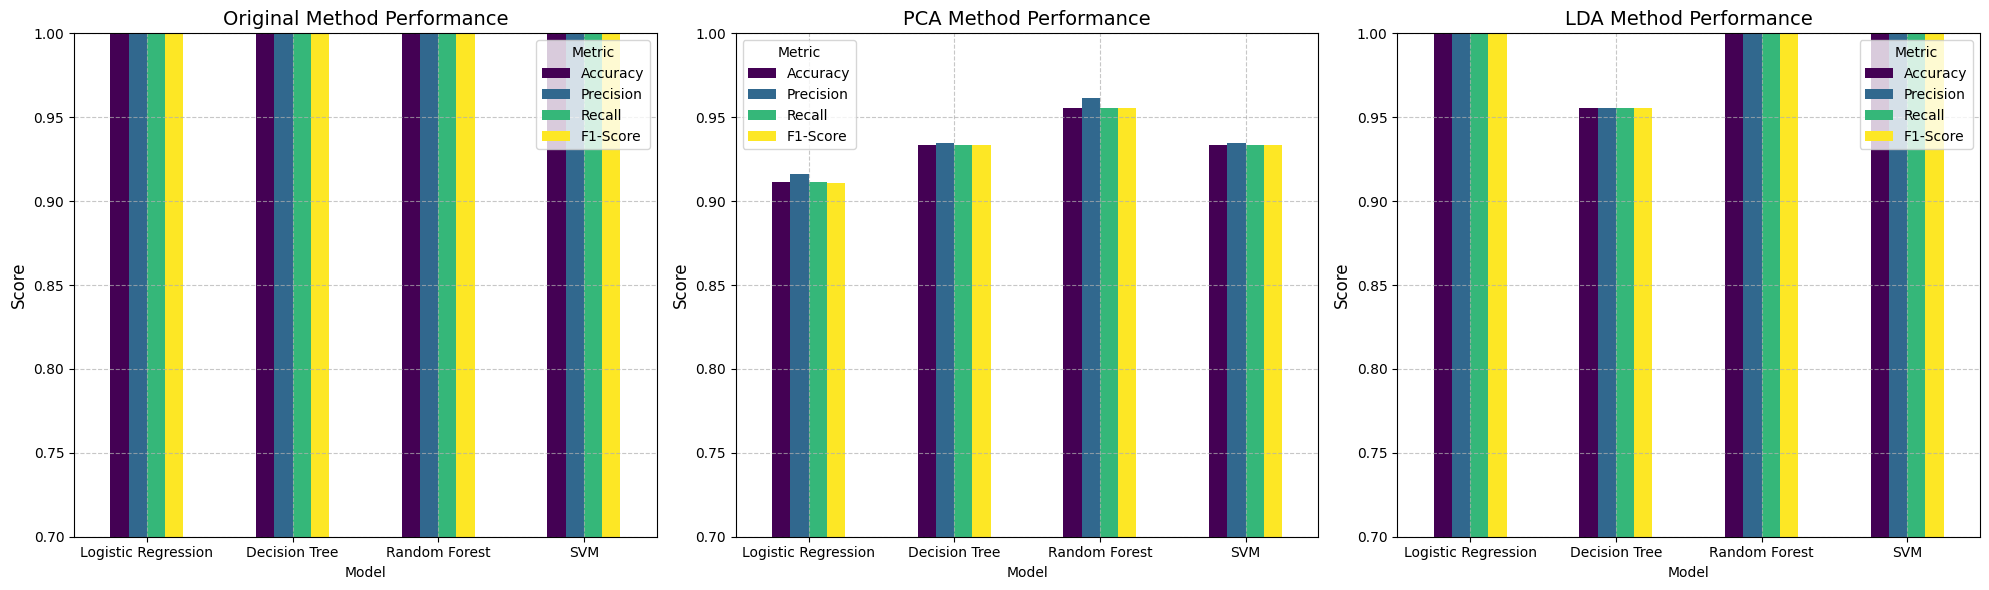

In [139]:
plot_model_comparison_by_method()
plt.show()

In [140]:
best_models = summary_df.loc[summary_df.groupby('Method')['Accuracy'].idxmax()]
print("\nBEST MODEL FOR EACH METHOD (Based on Accuracy)")
print("===========================================")
print(best_models[['Method', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score']].round(4))


BEST MODEL FOR EACH METHOD (Based on Accuracy)
     Method                Model  Accuracy  Precision  Recall  F1-Score
2       LDA  Logistic Regression    1.0000     1.0000  1.0000    1.0000
0  Original  Logistic Regression    1.0000     1.0000  1.0000    1.0000
7       PCA        Random Forest    0.9556     0.9615  0.9556    0.9553


In [141]:
def radar_chart():
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']

    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, polar=True)

    angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
    angles += angles[:1]

    methods = ['Original', 'PCA', 'LDA']
    colors = ['blue', 'green', 'red']

    for method, color in zip(methods, colors):
        values = avg_by_method.loc[method].values.flatten().tolist()
        values += values[:1]
        ax.plot(angles, values, color=color, linewidth=2, label=method)
        ax.fill(angles, values, color=color, alpha=0.25)

    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(angles[:-1]), metrics)

    ax.set_ylim(0.8, 1.0)
    plt.legend(loc='upper right')
    plt.title('Method Performance Comparison', size=15)

    return fig

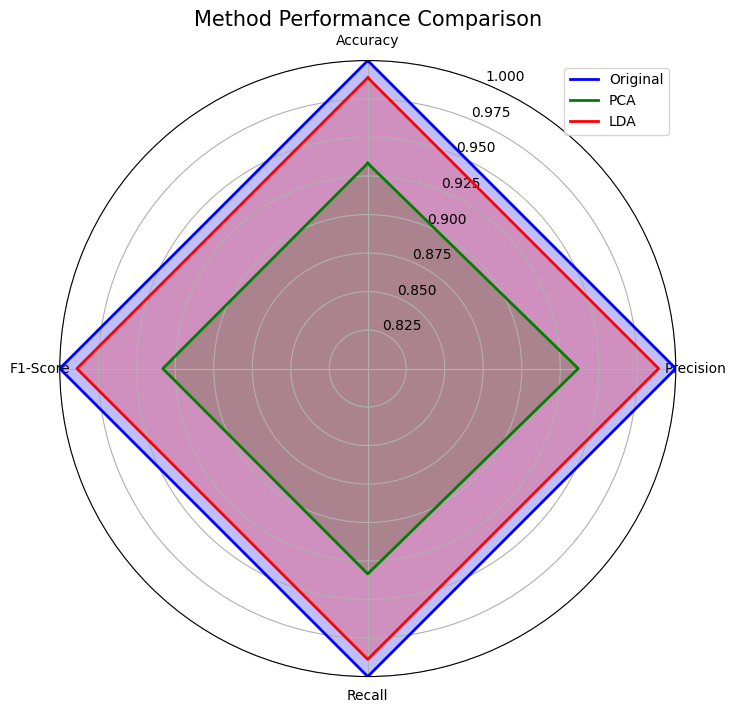

In [142]:
radar_chart()
plt.show()